--- Question 1: Tesla Data First 5 Rows ---
                       Date      Open      High       Low     Close  \
0 2010-06-29 00:00:00-04:00  1.266667  1.666667  1.169333  1.592667   
1 2010-06-30 00:00:00-04:00  1.719333  2.028000  1.553333  1.588667   
2 2010-07-01 00:00:00-04:00  1.666667  1.728000  1.351333  1.464000   
3 2010-07-02 00:00:00-04:00  1.533333  1.540000  1.247333  1.280000   
4 2010-07-06 00:00:00-04:00  1.333333  1.333333  1.055333  1.074000   

      Volume  Dividends  Stock Splits  
0  281494500        0.0           0.0  
1  257806500        0.0           0.0  
2  123282000        0.0           0.0  
3   77097000        0.0           0.0  
4  103003500        0.0           0.0  

--- Question 2: Tesla Revenue Last 5 Rows ---
          Date Revenue
48  2010-09-30      31
49  2010-06-30      28
50  2010-03-31      21
52  2009-09-30      46
53  2009-06-30      27

--- Question 3: GameStop Data First 5 Rows ---
                       Date      Open      High       Lo

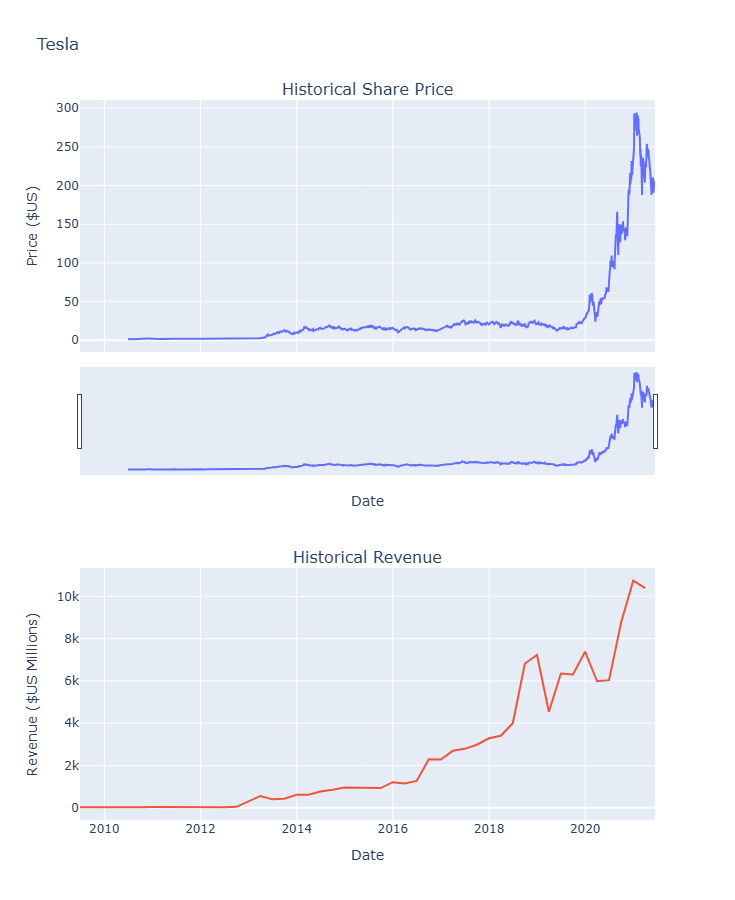

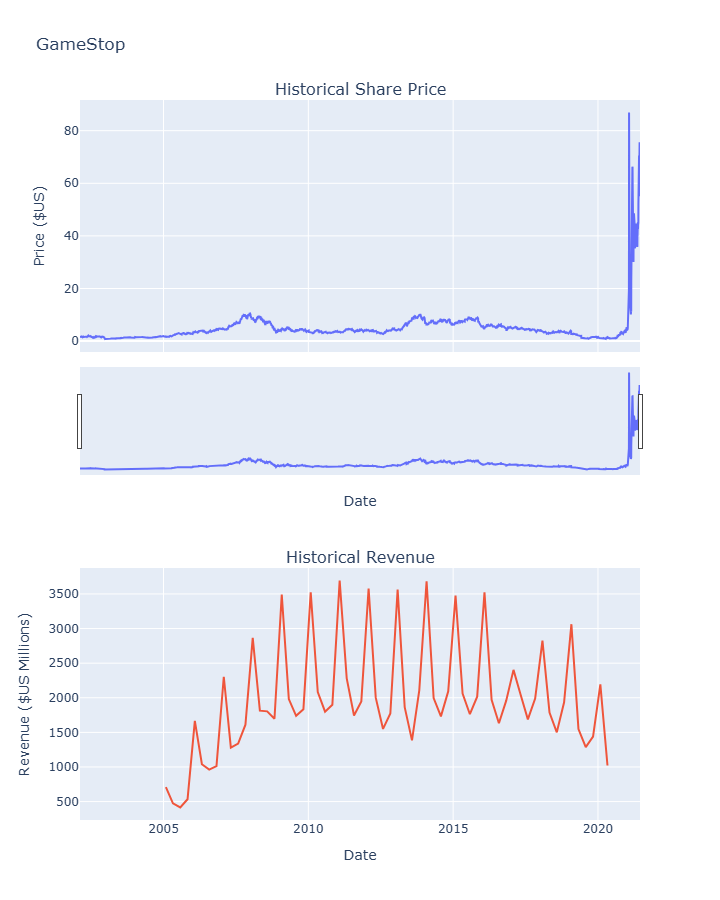

In [4]:
!pip install yfinance
!pip install pandas
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ---------------------------------------------------------
# Helper Function to Make Graph
# ---------------------------------------------------------
def make_graph(stock_data, revenue_data, stock):
    fig = make_subplots(
        rows=2, 
        cols=1, 
        shared_xaxes=True, 
        subplot_titles=("Historical Share Price", "Historical Revenue"), 
        vertical_spacing=0.3
    )
    
    # Filter dates up to specified bounds
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14'].copy()
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30'].copy()
    
    # Add Share Price Trace
    fig.add_trace(
        go.Scatter(
            x=pd.to_datetime(stock_data_specific.Date), 
            y=stock_data_specific.Close.astype("float"), 
            name="Share Price"
        ), 
        row=1, col=1
    )
    
    # Add Revenue Trace
    fig.add_trace(
        go.Scatter(
            x=pd.to_datetime(revenue_data_specific.Date), 
            y=revenue_data_specific.Revenue.astype("float"), 
            name="Revenue"
        ), 
        row=2, col=1
    )
    
    # Update Axes and Layout
    fig.update_xaxes(title_text="Date", row=1, col=1)
    fig.update_xaxes(title_text="Date", row=2, col=1)
    fig.update_yaxes(title_text="Price ($US)", row=1, col=1)
    fig.update_yaxes(title_text="Revenue ($US Millions)", row=2, col=1)
    
    fig.update_layout(
        showlegend=False, 
        height=900, 
        title=stock, 
        xaxis_rangeslider_visible=True
    )
    fig.show()


# ---------------------------------------------------------
# Question 1: Use yfinance to Extract Stock Data for Tesla
# ---------------------------------------------------------
tesla = yf.Ticker("TSLA")
tesla_data = tesla.history(period="max")
tesla_data.reset_index(inplace=True)

print("--- Question 1: Tesla Data First 5 Rows ---")
print(tesla_data.head())


# ---------------------------------------------------------
# Question 2: Use Webscraping to Extract Tesla Revenue Data
# ---------------------------------------------------------
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
html_data = requests.get(url).text
soup = BeautifulSoup(html_data, "html.parser")

tesla_revenue = pd.DataFrame(columns=["Date", "Revenue"])
tables = soup.find_all("table")

for row in tables[1].find("tbody").find_all("tr"):
    col = row.find_all("td")
    date = col[0].text
    revenue = col[1].text
    tesla_revenue = pd.concat([tesla_revenue, pd.DataFrame({"Date": [date], "Revenue": [revenue]})], ignore_index=True)

# Clean Revenue Column
tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(r'[,\$]', "", regex=True)
tesla_revenue.dropna(inplace=True)
tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]

print("\n--- Question 2: Tesla Revenue Last 5 Rows ---")
print(tesla_revenue.tail())


# ---------------------------------------------------------
# Question 3: Use yfinance to Extract Stock Data for GameStop
# ---------------------------------------------------------
gme = yf.Ticker("GME")
gme_data = gme.history(period="max")
gme_data.reset_index(inplace=True)

print("\n--- Question 3: GameStop Data First 5 Rows ---")
print(gme_data.head())


# ---------------------------------------------------------
# Question 4: Use Webscraping to Extract GameStop Revenue Data
# ---------------------------------------------------------
url_gme = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"
html_data_2 = requests.get(url_gme).text
soup_2 = BeautifulSoup(html_data_2, "html.parser")

gme_revenue = pd.DataFrame(columns=["Date", "Revenue"])
tables_2 = soup_2.find_all("table")

for row in tables_2[1].find("tbody").find_all("tr"):
    col = row.find_all("td")
    date = col[0].text
    revenue = col[1].text
    gme_revenue = pd.concat([gme_revenue, pd.DataFrame({"Date": [date], "Revenue": [revenue]})], ignore_index=True)

# Clean Revenue Column
gme_revenue["Revenue"] = gme_revenue['Revenue'].str.replace(r'[,\$]', "", regex=True)
gme_revenue.dropna(inplace=True)
gme_revenue = gme_revenue[gme_revenue['Revenue'] != ""]

print("\n--- Question 4: GameStop Revenue Last 5 Rows ---")
print(gme_revenue.tail())


# ---------------------------------------------------------
# Question 5: Plot Tesla Stock Graph
# ---------------------------------------------------------
make_graph(tesla_data, tesla_revenue, 'Tesla')


# ---------------------------------------------------------
# Question 6: Plot GameStop Stock Graph
# ---------------------------------------------------------
make_graph(gme_data, gme_revenue, 'GameStop')